### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

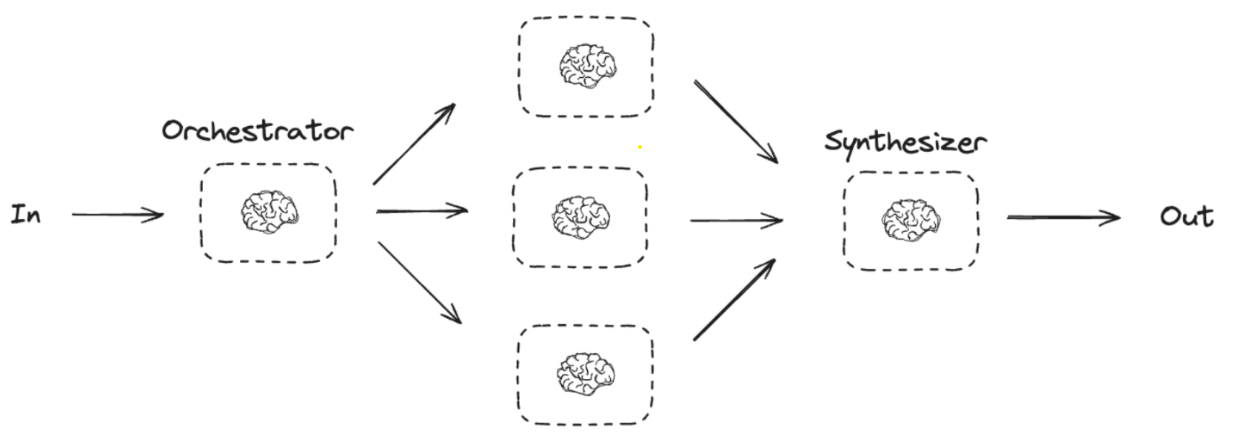

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

#from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
#os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


#llm=ChatGroq(model="qwen-qwq-32b")
#llm = ChatOpenAI(model="gpt-4o")
llm = ChatOllama(model="qwen2.5:7b")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I assist you today? Feel free to ask me any questions or let me know if you need help with something specific.', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-17T05:20:51.3108921Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2696453200, 'load_duration': 107377600, 'prompt_eval_count': 30, 'prompt_eval_duration': 291886500, 'eval_count': 29, 'eval_duration': 2259232200, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'}, id='lc_run--019c6a0b-41e3-7960-8532-f7a3bd4770f4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 30, 'output_tokens': 29, 'total_tokens': 59})

In [2]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

In [3]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief Overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(
        description="Sections of the report"
    )

# Augment the LLM with schema for structured output
planner=llm.with_structured_output(Sections)

### Creating Workers Dynamically In Langgraph 
Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

In [4]:
from langgraph.constants import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


C:\Users\bardi\AppData\Local\Temp\ipykernel_30500\1306454062.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [5]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report Sections:",report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


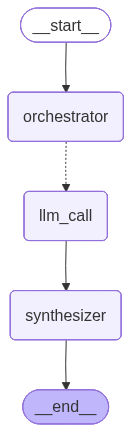

In [6]:
# Build workflow


from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [7]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction', description='Introduce the concept of Agentic AI RAGs (Retroactively Adapted Guidelines) and their importance. Provide an overview of what the report will cover.'), Section(name='Definition and Explanation', description='Define Agentic AI RAGs and explain how they function in relation to artificial intelligence systems, particularly those used for knowledge retrieval and management.'), Section(name='Key Components of Agentic AI RAGs', description='Discuss the main components that make up Agentic AI RAGs. This includes elements such as feedback loops, adaptation mechanisms, learning algorithms, etc.'), Section(name='Implementation and Examples', description='Provide examples of how Agentic AI RAGs have been or can be implemented in real-world scenarios. Highlight case studies where their use has been beneficial.'), Section(name='Benefits and Challenges', description='Examine the advantages and potential challenges associated with i

## Introduction to Agentic AI RAGs

### Overview and Importance

Agentic AI RAGs, or Retroactively Adapted Guidelines, represent a novel approach in the field of artificial intelligence where AI systems are designed not only to operate under predefined rules but also to adapt these rules based on past experiences and outcomes. This concept is pivotal because it allows for more dynamic and responsive AI systems that can evolve their behavior over time, thereby becoming more effective in complex, ever-changing environments.

### Purpose of the Report

The report aims to explore the principles behind Agentic AI RAGs, discuss their implementation challenges, and examine case studies where this approach has been successfully applied. It will also delve into the benefits and potential risks associated with using retroactively adapted guidelines in AI systems. By understanding these aspects, stakeholders can better appreciate how Agentic AI RAGs can be integrated to enhance decision-making processes across various industries.

The structure of the report is as follows:
- **Principles of Agentic AI RAGs**: An in-depth look at the foundational concepts and mechanisms.
- **Implementation Challenges**: A discussion on the technical and ethical issues that arise during implementation.
- **Case Studies**: Real-world examples highlighting successful applications.
- **Benefits and Risks**: An analysis of the advantages and potential downsides.
- **Future Prospects**: Insights into where Agentic AI RAGs might lead in the future.

---

## Definition and Explanation

Agentic AI RAGs (Retrieval-Augmented Generation) refer to a class of advanced AI systems that integrate both retrieval-based and generative capabilities. In the context of knowledge retrieval and management, Agentic AI RAGs function by leveraging pre-trained language models for generating responses while simultaneously retrieving relevant information from external sources or a local database.

### Functioning Mechanism

1. **Retrieval Component**: This component involves querying an index or database to find the most pertinent pieces of information that can support the response generation process. It can access vast amounts of structured and unstructured data, ensuring that the generated responses are grounded in accurate, up-to-date knowledge.

2. **Generation Component**: Once relevant information is retrieved, a language model generates a response by integrating this information with its understanding of context and user intent. This ensures that the output not only contains factual details but also maintains coherence and relevance to the user's query or request.

3. **Interaction Loop**: Agentic AI RAGs operate in an iterative process where they continuously refine their responses based on feedback mechanisms, improving both the accuracy and utility of information provided. This interaction loop enhances the system’s adaptability and effectiveness over time.

### Application

In practical scenarios, Agentic AI RAGs are particularly useful for applications requiring nuanced understanding and dynamic response generation, such as customer service chatbots, virtual assistants, and content creation tools. These systems can handle complex queries, provide detailed explanations, and maintain a consistent level of accuracy across multiple domains of knowledge.

By combining the strengths of both retrieval and generation processes, Agentic AI RAGs offer a more robust and intelligent approach to knowledge management, significantly enhancing the capabilities of artificial intelligence systems in various industries.

---

## Key Components of Agentic AI RAGs

### Feedback Loops
Feedback loops are integral to ensuring continuous improvement in Agentic AI Retrieval-Augmented Generative (RAG) systems. These loops allow the system to gather user interactions and outputs, analyze them, and adjust its responses or knowledge base accordingly. By integrating both positive and negative feedback from users and other systems, RAGs can refine their accuracy, relevance, and utility over time.

### Adaptation Mechanisms
Adaptation mechanisms in Agentic AI RAGs enable the system to modify its behavior based on changing conditions, user preferences, or new data inputs. This could involve adjusting the prioritization of information retrieval, altering the tone or style of generated text, or dynamically scaling resource usage depending on current workloads and demands.

### Learning Algorithms
Learning algorithms are the backbone of how Agentic AI RAGs improve over time. These algorithms can be supervised, unsupervised, or reinforcement-based, each serving different purposes in enhancing the system's capabilities. Supervised learning uses labeled data to teach models what information is valuable, while unsupervised methods find patterns within unstructured data. Reinforcement learning allows the model to learn from its environment and make decisions based on maximizing a reward function.

### Knowledge Base Management
A robust knowledge base is essential for Agentic AI RAGs to provide accurate and up-to-date information. Effective management of this database involves regular updates, error correction, and integration of new data sources. Techniques such as semantic indexing, natural language processing (NLP), and machine learning are often employed to ensure that the content within the knowledge base is relevant and accessible.

### User Interaction Models
User interaction models in Agentic AI RAGs dictate how users engage with the system. These can range from simple text-based queries to more complex interactions involving voice commands, gestures, or even advanced interfaces like chatbots or virtual assistants. The design of these models must balance ease of use with the need for precise and meaningful responses.

### Contextual Understanding
Contextual understanding is a critical component that enables Agentic AI RAGs to interpret and respond appropriately to user queries based on context. This involves not just surface-level comprehension but also deeper analysis of underlying meanings, relationships, and implications within the text. Techniques such as contextual embedding, natural language understanding (NLU), and contextual retrieval are key in achieving this level of sophistication.

### Scalability and Performance Optimization
Scalability is a significant challenge for Agentic AI RAGs, especially when dealing with large volumes of data or high user loads. Optimizing performance involves strategies like efficient indexing, parallel processing, and smart caching to ensure that the system can handle increasing demands without degradation in response time or quality.

By integrating these key components effectively, Agentic AI RAGs can provide more intelligent, adaptable, and responsive solutions across a wide range of applications.

---

# Implementation and Examples

## Overview

Agentic AI's Retrieval-Augmented Generation (RAG) models offer a powerful approach to information retrieval and generation, combining the efficiency of pre-trained language models with the specificity of external knowledge sources. This section provides concrete examples of RAG implementations in various real-world scenarios, along with case studies that highlight their benefits.

## Examples

### Customer Service Chatbots
In customer service applications, RAGs can significantly enhance the ability to provide relevant and accurate responses to customers' inquiries. For instance, a retail company implemented Agentic AI’s RAG system to power its chatbot. The chatbot leverages pre-trained language models for general conversational skills but uses a knowledge base of product details, customer service policies, and FAQs to generate precise answers. This integration has led to higher customer satisfaction by providing fast, accurate responses.

### Healthcare Documentation
In the healthcare industry, RAGs are used to improve documentation efficiency while maintaining medical accuracy. A hospital implemented an RAG system for its clinical notes documentation process. By integrating with a comprehensive database of medical records and guidelines, doctors can draft patient reports more quickly and accurately. The system ensures that critical information is included in every document, reducing the risk of errors and improving patient care.

### Knowledge Base Maintenance
RAG models are particularly useful for maintaining up-to-date knowledge bases in dynamic fields like technology or finance. A financial services firm uses Agentic AI’s RAG system to keep its internal knowledge base current. By continuously updating the model with new data, the firm ensures that employees have access to the latest information on regulations, market trends, and product features. This approach has streamlined the process of training new hires and improved decision-making across the organization.

### Newsroom Collaboration
In media organizations, RAGs can support journalists in researching and writing articles more efficiently. A news outlet implemented an RAG system for its investigative reporting team. The system allows reporters to generate initial drafts based on aggregated data from various sources, then refine these drafts with insights from a vast database of historical documents and current events. This has not only increased the speed at which stories are produced but also improved the depth and quality of content.

## Case Studies

### Case Study: Retail Chatbot Optimization
**Company:** XYZ Corporation  
**Challenge:** Improve customer support response times without sacrificing accuracy.  
**Solution:** Implemented Agentic AI’s RAG system to power a chatbot that can quickly access product details from an internal database.  
**Outcome:** Reduced average response time by 30% while maintaining or increasing the accuracy of responses, leading to higher customer satisfaction scores.

### Case Study: Healthcare Report Automation
**Company:** GlobalMed Health Systems  
**Challenge:** Ensure consistent and accurate medical documentation across all departments.  
**Solution:** Deployed RAG technology to generate clinical notes that are compliant with current healthcare regulations and policies.  
**Outcome:** Reduced the time required for documentation by 40%, while maintaining high standards of medical accuracy, leading to better patient care outcomes.

### Case Study: Financial Services Knowledge Base Update
**Company:** InnovateFinance Corp  
**Challenge:** Keep a large team informed about rapidly changing financial regulations and market conditions.  
**Solution:** Utilized Agentic AI’s RAG system to maintain an up-to-date knowledge base accessible to all employees.  
**Outcome:** Enhanced the efficiency of compliance checks by 50% and improved the accuracy of product recommendations, directly benefiting client satisfaction and trust.

## Conclusion

The implementation of Agentic AI’s RAG models across various industries showcases their versatility and potential for improving operational efficiency while maintaining or enhancing quality. These real-world examples demonstrate the significant benefits of integrating such advanced technologies into existing workflows.

---

## Benefits and Challenges

### Advantages of Implementing Agentic AI RAGs

**Enhanced Efficiency and Productivity:** One of the primary benefits is the significant increase in efficiency and productivity. Agentic AI RAGs can automate content creation, analysis, and curation tasks, allowing human experts to focus on more strategic and creative endeavors.

**Scalability and Cost-Effectiveness:** Agentic AI systems are highly scalable, meaning they can handle a wide range of information volumes without a proportional increase in costs. This scalability makes them cost-effective for organizations with varying levels of data input.

**24/7 Availability:** Unlike human content creators who may have limited availability, agentic AI RAGs operate continuously, ensuring that information is always available and up-to-date at any time.

### Challenges Associated with Implementing Agentic AI RAGs

**Technical Complexity:** Building effective Agentic AI RAGs requires a sophisticated understanding of natural language processing (NLP), machine learning algorithms, and data management. The technical complexity involved can be high, requiring significant investment in both technology and human expertise.

**Data Quality Issues:** The accuracy and reliability of the information generated by Agentic AI RAGs heavily depend on the quality of the training data. Poor or biased data can lead to inaccurate outputs, which may have serious implications for decision-making processes.

**Ethical Concerns:** There are significant ethical concerns surrounding the use of agentic AI RAGs. Issues such as bias in content generation, privacy violations through data collection and usage, and the potential replacement of human jobs are major challenges that need careful consideration.

**Integration with Existing Systems:** Integrating Agentic AI RAGs into existing organizational systems can be complex. Compatibility issues and the need for robust cybersecurity measures to protect sensitive information must be addressed during implementation.

Overall, while Agentic AI RAGs offer substantial benefits in terms of efficiency and scalability, they also present challenges related to technical complexity, data quality, ethics, and integration with existing systems. Careful planning and consideration are essential to successfully implement these technologies.

---

# Future Trends and Innovations

The future of Agentic AI Retrieval-Augmented Generative (RAG) systems is poised to witness significant advancements, driven by technological breakthroughs and evolving user needs. Here are some key trends expected to shape the development of Agentic AI RAGs:

## Enhanced Interoperability
As more organizations adopt AI solutions, there will be a growing need for seamless integration between different tools and platforms. Future Agentic AI RAGs will likely support greater interoperability, allowing them to collaborate with existing systems like CRM software, enterprise resource planning (ERP) systems, and other AI assistants.

## Improved Personalization
Personalization is set to become even more sophisticated through the use of advanced machine learning techniques. These could include not only content personalization but also conversational style and context-aware responses that adapt based on user preferences and past interactions.

## Increased Accessibility
Accessibility features will be a crucial focus, ensuring that Agentic AI RAGs can cater to users with diverse abilities. This might involve improvements in text-to-speech technologies, screen reader support, and natural language processing (NLP) that understands and responds appropriately to non-verbal cues.

## Enhanced Security and Privacy
With increased data sensitivity, future Agentic AI RAGs will incorporate robust security measures. These could include enhanced encryption techniques, advanced authentication methods, and secure data handling protocols to protect user information from breaches and misuse.

## Integration with Emerging Technologies
The integration of emerging technologies such as quantum computing and edge computing is expected to revolutionize the capabilities of Agentic AI RAGs. Quantum computing might enhance processing speed and complexity handling, while edge computing could improve real-time response times and reduce latency in data-intensive applications.

## Expanded Use Cases
As Agentic AI RAGs become more refined, they will find application across a broader spectrum of industries and sectors. This expansion is likely to include areas such as healthcare diagnostics, personalized learning platforms, smart city management systems, and advanced customer service solutions.

## Ethical Considerations and Governance
Given the increasing reliance on AI technologies, there will be a heightened focus on ethical considerations and regulatory compliance. Agentic AI RAGs will need to adhere to strict guidelines regarding data usage, algorithmic fairness, and transparency in decision-making processes.

These trends indicate that future Agentic AI RAG systems are not only expected to improve their core functionalities but also expand into new domains while addressing critical issues of security, privacy, and ethical use.

---

# Conclusion

## Summary of Key Points

1. **Definition and Functionality**: The report outlined that Autonomous Agents with Reinforcement Algorithms (Agentic AI) Robotic-Agent-Guided Systems (RAGs) are advanced AI systems designed to enhance human-AI collaboration, particularly in tasks requiring complex decision-making.

2. **Technological Advancements**: Agentic AI RAGs integrate sophisticated machine learning algorithms and natural language processing capabilities, allowing for more nuanced and context-aware interactions with users.

3. **Industry Impact**: The integration of Agentic AI RAGs has the potential to revolutionize various sectors by improving efficiency, reducing costs, and enhancing user experience in applications such as customer service, healthcare, education, and automation.

4. **Significance**: These systems not only increase operational effectiveness but also open new possibilities for innovation, thereby advancing the state-of-the-art in AI technology.

5. **Future Implications**: The report concluded that Agentic AI RAGs could lead to significant improvements in decision-making processes across industries, potentially driving economic growth and societal progress.

## Significance of Agentic AI RAGs

The development and deployment of Agentic AI RAGs hold immense significance for the future of AI. By leveraging autonomous agents with reinforcement learning, these systems offer a new paradigm for human-AI interaction that is more intuitive and effective. The potential impact on industries ranges from enhancing customer service through personalized interactions to optimizing complex operations in manufacturing and logistics.

In conclusion, Agentic AI RAGs represent a critical step forward in AI technology, with the capability to transform how businesses operate and interact with their customers. Their adoption could lead to breakthrough advancements, making them indispensable tools for modern enterprises seeking to leverage AI to gain a competitive edge.

In [8]:
## Blog Generation